# 05 — DDPM

Denoising Diffusion Probabilistic Model — trained from scratch on chest X-rays.

**Architecture:** HuggingFace diffusers UNet2DModel

**Training:** DDPMScheduler with 1000 timesteps

**Note:** Training takes 4-6 hours on Kaggle T4. Checkpoints saved every 10 epochs.

## Setup

In [1]:
!pip install torchxrayvision -q
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from PIL import Image
from tqdm import tqdm
from scipy import linalg

from diffusers import UNet2DModel, DDPMScheduler, DDPMPipeline
from diffusers.optimization import get_cosine_schedule_with_warmup

import torchxrayvision as xrv

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 33.4 MB/s eta 0:00:00


Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


Device: cuda


In [2]:
# hyperparameters
IMG_SIZE = 64
CHANNELS = 1
BATCH_SIZE = 32
LR = 1e-4
N_EPOCHS = 50
NUM_TIMESTEPS = 1000
N_GENERATE = 100

In [3]:
# paths
# DATA_DIR = Path("../data")  # for local use
DATA_DIR = Path("/kaggle/input/datasets/lakshyarathi/lungpp/data")
REAL_DIR = DATA_DIR / "pneumonia"

OUTPUT_DIR = Path("outputs/05_ddpm")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

## Dataset Loading

In [4]:
class XrayDataset(Dataset):
    def __init__(self, folder: Path, transform=None):
        self.paths = sorted([
            p for p in folder.iterdir()
            if p.suffix.lower() in {'.png', '.jpg', '.jpeg'} and not p.name.startswith('.')
        ])
        self.transform = transform
    
    def __len__(self):
        return len(self.paths)
    
    def __getitem__(self, idx):
        img = Image.open(self.paths[idx]).convert('L')
        if self.transform:
            img = self.transform(img)
        return img

In [5]:
transform = transforms.Compose([
    transforms.Resize(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])  # scale to [-1, 1]
])

dataset = XrayDataset(REAL_DIR, transform=transform)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

print(f"Dataset size: {len(dataset)}")
print(f"Batches per epoch: {len(dataloader)}")

Dataset size: 3875
Batches per epoch: 121


## Model Architecture

Small UNet from diffusers, sized for 64x64 grayscale images.

In [6]:
model = UNet2DModel(
    sample_size=IMG_SIZE,
    in_channels=CHANNELS,
    out_channels=CHANNELS,
    layers_per_block=2,
    block_out_channels=(64, 128, 256, 256),
    down_block_types=(
        "DownBlock2D",
        "DownBlock2D",
        "AttnDownBlock2D",
        "DownBlock2D",
    ),
    up_block_types=(
        "UpBlock2D",
        "AttnUpBlock2D",
        "UpBlock2D",
        "UpBlock2D",
    ),
)

model = model.to(device)
print(f"Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Model parameters: 25,302,657


In [7]:
noise_scheduler = DDPMScheduler(
    num_train_timesteps=NUM_TIMESTEPS,
    beta_schedule="linear"
)

## Training

In [8]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR)

num_training_steps = N_EPOCHS * len(dataloader)
lr_scheduler = get_cosine_schedule_with_warmup(
    optimizer=optimizer,
    num_warmup_steps=500,
    num_training_steps=num_training_steps
)

In [9]:
train_losses = []

print("Starting training...")
print(f"This will take 4-6 hours on Kaggle T4 GPU")

for epoch in range(N_EPOCHS):
    model.train()
    epoch_loss = 0.0
    
    pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{N_EPOCHS}")
    
    for batch_idx, images in enumerate(pbar):
        images = images.to(device)
        
        # sample noise
        noise = torch.randn_like(images)
        
        # sample random timesteps
        timesteps = torch.randint(
            0, NUM_TIMESTEPS, (images.shape[0],), device=device
        ).long()
        
        # add noise to images based on timestep
        noisy_images = noise_scheduler.add_noise(images, noise, timesteps)
        
        # predict noise
        noise_pred = model(noisy_images, timesteps).sample
        
        # MSE loss between predicted and actual noise
        loss = F.mse_loss(noise_pred, noise)
        
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        lr_scheduler.step()
        
        epoch_loss += loss.item()
        pbar.set_postfix({'loss': f'{loss.item():.4f}'})
    
    avg_loss = epoch_loss / len(dataloader)
    train_losses.append(avg_loss)
    print(f"Epoch {epoch+1}: loss={avg_loss:.4f}")
    
    # checkpoint every 10 epochs
    if (epoch + 1) % 10 == 0:
        checkpoint_path = CHECKPOINT_DIR / f"checkpoint_epoch_{epoch+1}.pt"
        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': lr_scheduler.state_dict(),
            'train_losses': train_losses,
        }, checkpoint_path)
        print(f"Saved checkpoint: {checkpoint_path}")

print("Training complete!")

Starting training...
This will take 4-6 hours on Kaggle T4 GPU


Epoch 1/50: 100%|██████████| 121/121 [00:55<00:00,  2.19it/s, loss=0.1035]


Epoch 1: loss=0.4417


Epoch 2/50: 100%|██████████| 121/121 [00:59<00:00,  2.05it/s, loss=0.0526]


Epoch 2: loss=0.0546


...

Epoch 48: loss=0.0198


Epoch 49/50: 100%|██████████| 121/121 [01:01<00:00,  1.97it/s, loss=0.0151]


Epoch 49: loss=0.0205


Epoch 50/50: 100%|██████████| 121/121 [01:01<00:00,  1.97it/s, loss=0.0224]


Epoch 50: loss=0.0195
Saved checkpoint: outputs/05_ddpm/checkpoints/checkpoint_epoch_50.pt
Training complete!


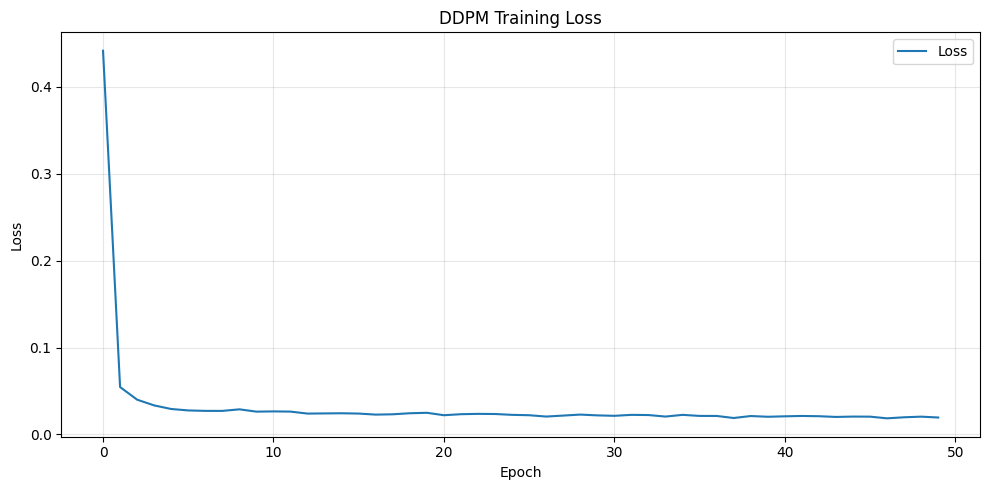

In [10]:
plt.figure(figsize=(10, 5))
plt.plot(train_losses, label='Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('DDPM Training Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "training_curve.png", dpi=150)
plt.show()

## Generate 100 Images

In [11]:
generated_dir = OUTPUT_DIR / "images"
generated_dir.mkdir(parents=True, exist_ok=True)

model.eval()
generated_paths = []

In [12]:
# create pipeline for generation
pipeline = DDPMPipeline(unet=model, scheduler=noise_scheduler)
pipeline.to(device)

DDPMPipeline {
  "_class_name": "DDPMPipeline",
  "_diffusers_version": "0.36.0",
  "scheduler": [
    "diffusers",
    "DDPMScheduler"
  ],
  "unet": [
    "diffusers",
    "UNet2DModel"
  ]
}

In [13]:
# generate in batches for efficiency
batch_size = 10
n_batches = N_GENERATE // batch_size

for batch_idx in tqdm(range(n_batches), desc="Generating"):
    with torch.no_grad():
        images = pipeline(
            batch_size=batch_size,
            generator=torch.Generator(device=device).manual_seed(SEED + batch_idx),
            num_inference_steps=NUM_TIMESTEPS,
            output_type="numpy"
        ).images
    
    for i, img in enumerate(images):
        idx = batch_idx * batch_size + i
        # images are in range [-1, 1], convert to [0, 255]
        img = img.squeeze()
        # img = ((img + 1) / 2 * 255).clip(0, 255).astype(np.uint8)
        img = (img * 255).clip(0, 255).astype(np.uint8)
        img = Image.fromarray(img, mode='L')
        
        out_path = generated_dir / f"{idx:04d}.png"
        img.save(out_path, 'PNG')
        generated_paths.append(out_path)

print(f"Generated {len(generated_paths)} images")

Generating:   0%|          | 0/10 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating:  10%|█         | 1/10 [00:57<08:37, 57.46s/it]

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating:  20%|██        | 2/10 [01:54<07:36, 57.09s/it]

...

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating:  90%|█████████ | 9/10 [08:32<00:56, 56.78s/it]

  0%|          | 0/1000 [00:00<?, ?it/s]

Generating: 100%|██████████| 10/10 [09:28<00:00, 56.87s/it]

Generated 100 images


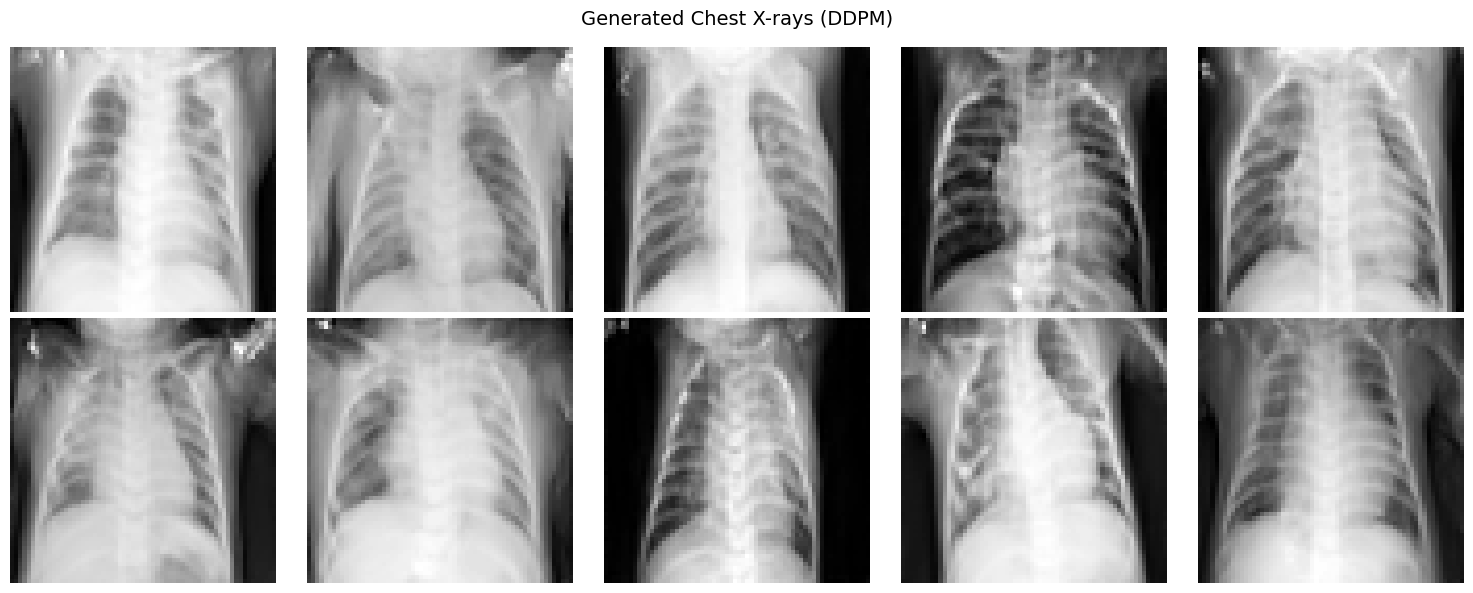

In [14]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
fig.suptitle("Generated Chest X-rays (DDPM)", fontsize=14)

for ax, img_path in zip(axes.flat, generated_paths[:10]):
    img = Image.open(img_path)
    ax.imshow(img, cmap='gray')
    ax.axis('off')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "generated_samples.png", dpi=150)
plt.show()

## Evaluate — FID (domain-adapted, DenseNet121 features)

In [15]:
xrv_model = xrv.models.DenseNet(weights="densenet121-res224-all")
xrv_model = xrv_model.to(device)
xrv_model.eval()

feature_extractor = nn.Sequential(*list(xrv_model.features.children()))
feature_extractor = feature_extractor.to(device)
feature_extractor.eval()

If this fails you can run `wget https://github.com/mlmed/torchxrayvision/releases/download/v1/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt -O /root/.torchxrayvision/models_data/nih-pc-chex-mimic_ch-google-openi-kaggle-densenet121-d121-tw-lr001-rot45-tr15-sc15-seed0-best.pt`
[██████████████████████████████████████████████████]


Sequential(
  (0): Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (2): ReLU(inplace=True)
  (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (4): _DenseBlock(
    (denselayer1): _DenseLayer(
      (norm1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(64, 128, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (norm2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu2): ReLU(inplace=True)
      (conv2): Conv2d(128, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    )
    (denselayer2): _DenseLayer(
      (norm1): BatchNorm2d(96, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu1): ReLU(inplace=True)
      (conv1): Conv2d(96, 128, kernel_size=(1, 1), stride=(

In [16]:
def load_and_preprocess_for_xrv(img_path):
    img = Image.open(img_path).convert('L')
    img = img.resize((224, 224), Image.LANCZOS)
    img = np.array(img, dtype=np.float32)
    img = (img / 255.0) * 2048 - 1024
    img = img[np.newaxis, ...]
    return torch.tensor(img, dtype=torch.float32)


def extract_features(image_paths, batch_size=32):
    features = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Extracting features"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        with torch.no_grad():
            feat = feature_extractor(batch)
            feat = feat.mean(dim=[2, 3])
            features.append(feat.cpu().numpy())
    return np.concatenate(features, axis=0)


def compute_fid(real_features, fake_features):
    if len(real_features) < 2 or len(fake_features) < 2:
        return None
    mu_real = np.mean(real_features, axis=0)
    mu_fake = np.mean(fake_features, axis=0)
    sigma_real = np.cov(real_features, rowvar=False)
    sigma_fake = np.cov(fake_features, rowvar=False)
    eps = 1e-6
    sigma_real += np.eye(sigma_real.shape[0]) * eps
    sigma_fake += np.eye(sigma_fake.shape[0]) * eps
    diff = mu_real - mu_fake
    try:
        covmean, _ = linalg.sqrtm(sigma_real @ sigma_fake, disp=False)
        if np.iscomplexobj(covmean):
            covmean = covmean.real
        if not np.isfinite(covmean).all():
            return None
        fid = float(diff @ diff + np.trace(sigma_real + sigma_fake - 2 * covmean))
        return fid if np.isfinite(fid) else None
    except Exception:
        return None

In [17]:
real_paths = sorted([p for p in REAL_DIR.iterdir() if p.suffix == '.png'])[:N_GENERATE]

print("Extracting features from real images...")
real_features = extract_features(real_paths)

print("Extracting features from generated images...")
fake_features = extract_features(generated_paths)

fid_score = compute_fid(real_features, fake_features)
print(f"\nDomain-adapted FID (DenseNet121): {fid_score:.2f}")

Extracting features from real images...


Extracting features: 100%|██████████| 4/4 [00:00<00:00,  4.19it/s]


Extracting features from generated images...


Extracting features: 100%|██████████| 4/4 [00:00<00:00, 10.17it/s]



Domain-adapted FID (DenseNet121): 8.96


## Evaluate — Label + TSTR (torchxrayvision)

In [18]:
def label_images(image_paths, batch_size=32):
    all_predictions = []
    for i in tqdm(range(0, len(image_paths), batch_size), desc="Labeling"):
        batch_paths = image_paths[i:i+batch_size]
        batch = torch.stack([load_and_preprocess_for_xrv(p) for p in batch_paths])
        batch = batch.to(device)
        with torch.no_grad():
            outputs = xrv_model(batch)
            all_predictions.append(outputs.cpu().numpy())
    return np.concatenate(all_predictions, axis=0)

In [19]:
predictions = label_images(generated_paths)
pathology_names = xrv_model.pathologies

pneumonia_idx = next(
    (i for i, name in enumerate(pathology_names) if 'lung opacity' in name.lower()),
    None
)
print(f"Using pathology index {pneumonia_idx}: {pathology_names[pneumonia_idx]}")

Labeling: 100%|██████████| 4/4 [00:00<00:00,  6.10it/s]

Using pathology index 16: Lung Opacity


In [20]:
pneumonia_scores = predictions[:, pneumonia_idx]
threshold = 0.5
positives = (pneumonia_scores > threshold).sum()
tstr_accuracy = positives / len(pneumonia_scores) * 100

print(f"\nProxy TSTR Results:")
print(f"  Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"  Classified as pneumonia (>{threshold}): {positives}/{len(pneumonia_scores)} ({tstr_accuracy:.1f}%)")


Proxy TSTR Results:
  Mean pneumonia score: 0.904
  Classified as pneumonia (>0.5): 100/100 (100.0%)


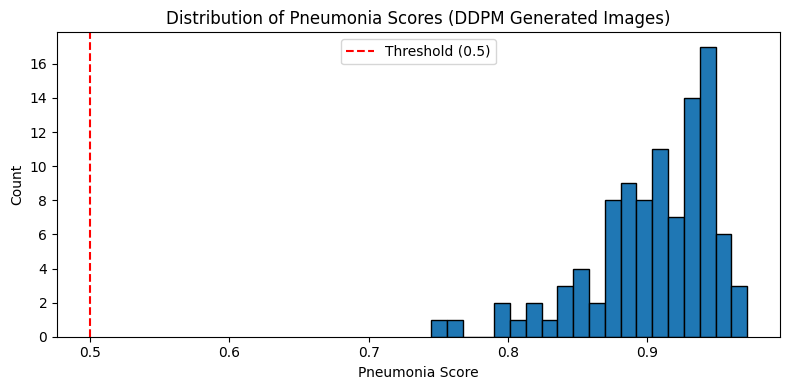

In [21]:
plt.figure(figsize=(8, 4))
plt.hist(pneumonia_scores, bins=20, edgecolor='black')
plt.axvline(threshold, color='red', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Pneumonia Score')
plt.ylabel('Count')
plt.title('Distribution of Pneumonia Scores (DDPM Generated Images)')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "pneumonia_scores.png", dpi=150)
plt.show()

## Export (images/ + labels.csv + metrics.json)

In [22]:
labels_df = pd.DataFrame({
    'filename': [p.name for p in generated_paths],
    'pneumonia_score': pneumonia_scores,
    'predicted_label': ['pneumonia' if s > threshold else 'normal' for s in pneumonia_scores]
})

for i, name in enumerate(pathology_names):
    labels_df[name] = predictions[:, i]

labels_path = OUTPUT_DIR / "labels.csv"
labels_df.to_csv(labels_path, index=False)
print(f"Saved labels to {labels_path}")

Saved labels to outputs/05_ddpm/labels.csv


In [23]:
metrics = {
    'model': 'ddpm',
    'n_generated': len(generated_paths),
    'fid_domain_adapted': fid_score,
    'tstr_accuracy': tstr_accuracy,
    'mean_pneumonia_score': float(pneumonia_scores.mean()),
    'epochs': N_EPOCHS,
    'batch_size': BATCH_SIZE,
    'num_timesteps': NUM_TIMESTEPS,
    'learning_rate': LR,
    'final_loss': train_losses[-1] if train_losses else None,
    'seed': SEED
}

metrics_path = OUTPUT_DIR / "metrics.json"
with open(metrics_path, 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Saved metrics to {metrics_path}")
print(json.dumps(metrics, indent=2))

Saved metrics to outputs/05_ddpm/metrics.json
{
  "model": "ddpm",
  "n_generated": 100,
  "fid_domain_adapted": 8.962898957707559,
  "tstr_accuracy": 100.0,
  "mean_pneumonia_score": 0.9040848612785339,
  "epochs": 50,
  "batch_size": 32,
  "num_timesteps": 1000,
  "learning_rate": 0.0001,
  "final_loss": 0.019496977864187366,
  "seed": 42
}


## Results

In [24]:
print("="*50)
print("DDPM RESULTS")
print("="*50)
print(f"Images generated: {len(generated_paths)}")
print(f"Training epochs: {N_EPOCHS}")
print(f"Domain-adapted FID: {fid_score:.2f}")
print(f"Proxy TSTR accuracy: {tstr_accuracy:.1f}%")
print(f"Mean pneumonia score: {pneumonia_scores.mean():.3f}")
print(f"Final loss: {train_losses[-1]:.4f}")
print("="*50)

DDPM RESULTS
Images generated: 100
Training epochs: 50
Domain-adapted FID: 8.96
Proxy TSTR accuracy: 100.0%
Mean pneumonia score: 0.904
Final loss: 0.0195
